In [1]:
from model_driver import driver
from iotools import read_results
import matplotlib.pyplot as plt

In [2]:
# runs model
outputfile = driver(create_ncf=True, param_module="parameters_fields")
# reads results from .nc-file
results = read_results(outputfile)

*** Running model ***
*** Writing results to netCDF4-file, subset 1/5 ***
*** Writing results to netCDF4-file, subset 2/5 ***
*** Writing results to netCDF4-file, subset 3/5 ***
*** Writing results to netCDF4-file, subset 4/5 ***
*** Writing results to netCDF4-file, subset 5/5 ***
--- Running time 12.90 seconds ---
--- Results are in file: results/202602260929.nc ---


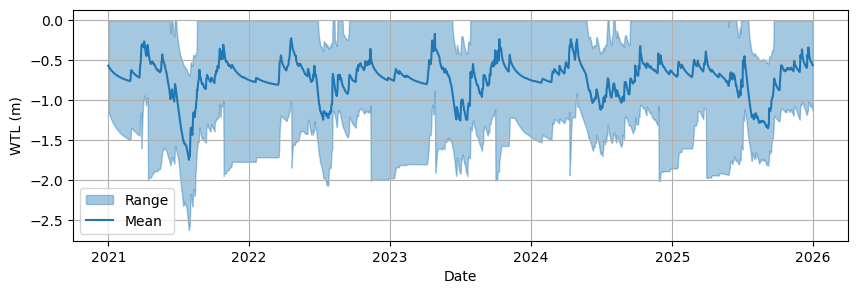

In [ ]:
da_min = results['soil_ground_water_level'].min(dim='j')[:,0]
da_max = results['soil_ground_water_level'].max(dim='j')[:,0]

# Extract the time coordinate (replace 'date' with your actual time dim name if different)
time = results['date'].values

# Plot
plt.figure(figsize=(10, 3))
plt.fill_between(time, da_min, da_max, color='tab:blue', alpha=0.4, label='Range')
plt.plot(time, results['soil_ground_water_level'].mean(dim='j'), color='tab:blue', label='Mean')
plt.xlabel("Date")
plt.ylabel("WTL (m)")
plt.legend()
plt.grid(True)
#plt.savefig('figs/wtl.png', dpi=300, bbox_inches="tight")

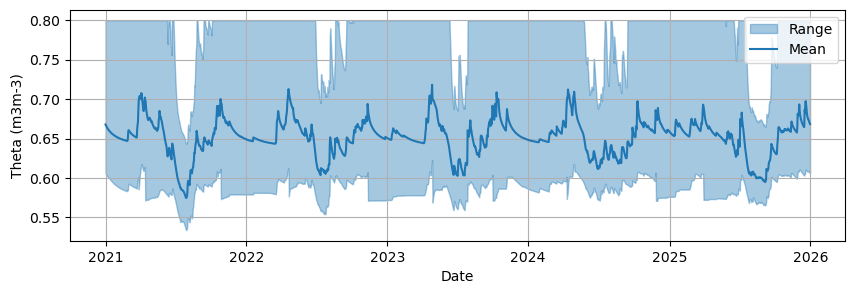

In [4]:
import matplotlib.pyplot as plt

da_min = results['soil_rootzone_moisture'].min(dim='j')[:,0]
da_max = results['soil_rootzone_moisture'].max(dim='j')[:,0]

# Extract the time coordinate (replace 'date' with your actual time dim name if different)
time = results['date'].values

# Plot
plt.figure(figsize=(10, 3))
plt.fill_between(time, da_min, da_max, color='tab:blue', alpha=0.4, label='Range')
plt.plot(time, results['soil_rootzone_moisture'].mean(dim='j'), color='tab:blue', label='Mean')
plt.xlabel("Date")
plt.ylabel("Theta (m3m-3)")
plt.legend()
plt.grid(True)
plt.savefig('figs/theta.png', dpi=300, bbox_inches="tight")

In [5]:
results.close()